Quimb not available.
(601,)
(401,)
epsilon=5.050000000000001 delta=7.8 chi=-0.1 kappa=0.625
[-8.9600767   8.03192785] [-10.24148717  -7.78552331]
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          5.17e+00       6.77e-01         10001          10000     
       2          5.45e+00       2.08e-01         20001          19510     
       3          2.94e+00       7.68e-02         39511          37616     
       4          1.82e-02       2.14e-01         77127            0       
       5          1.10e-02       4.18e-02         77127            0       
Solved in 5 iterations, number of nodes 77127. 
Maximum relative residual: 1.10e-02 
Maximum boundary residual: 4.18e-02


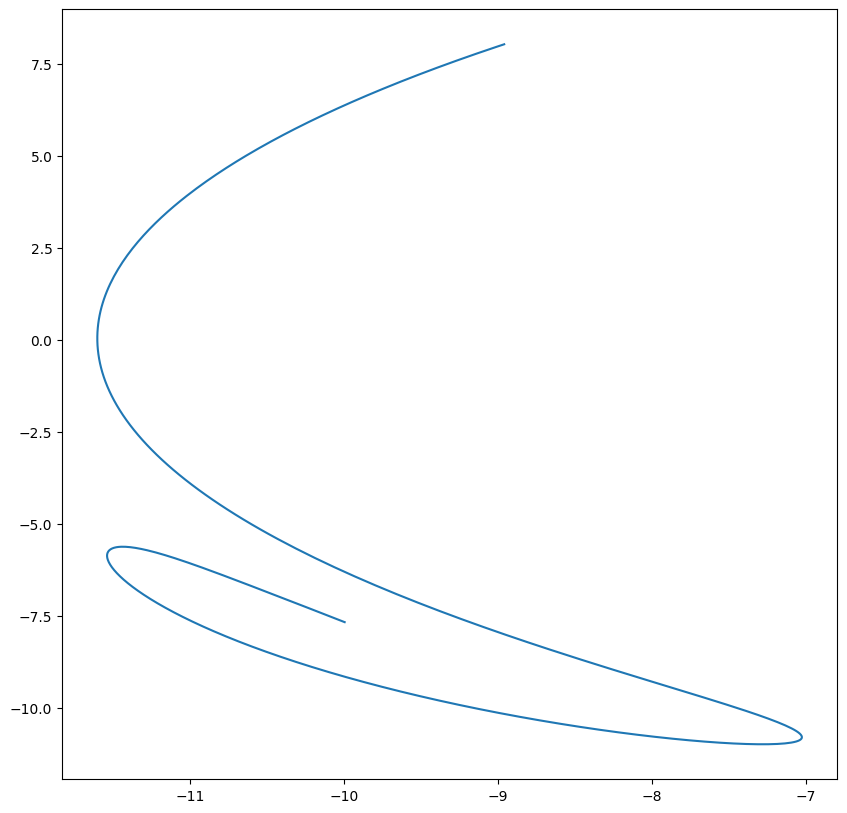

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  1.000e-04 ...  8.000e+00  8.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7f43b0efe250>
             p: None
             y: [[-9.997e+00 -9.997e+00 ... -8.960e+00 -8.960e+00]
                 [-7.678e+00 -7.677e+00 ...  8.032e+00  8.032e+00]
                 [ 4.172e-01  4.173e-01 ...  2.687e-05  2.686e-05]
                 [ 2.934e-01  2.935e-01 ... -1.585e-05 -1.584e-05]]
            yp: [[-2.337e+00 -2.337e+00 ...  1.212e-04  1.211e-04]
                 [ 3.849e+00  3.849e+00 ...  1.685e-04  1.684e-04]
                 [ 4.921e-01  4.919e-01 ... -5.824e-05 -5.821e-05]
                 [ 4.452e-01  4.450e-01 ...  3.434e-05  3.433e-05]]
 rms_residuals: [ 1.389e-03  1.389e-03 ...  1.431e-11  1.324e-11]
         niter: 5


In [1]:
import numpy as np
import scipy


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/00-attempt/map.npz")
epsilon_idx = 101
kappa_idx = 50
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def boundary_condition_func(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )


t_guess = np.linspace(0.0, 8.0, 10001)
y_guess = (
    keldysh_focus_point[:, np.newaxis]
    + t_guess[np.newaxis, :]
    * (keldysh_saddle_point - keldysh_focus_point)[:, np.newaxis]
    / t_guess[-1]
)
wrapper = lambda x, y: eom.y_dot_func(y)
res = scipy.integrate.solve_bvp(
    wrapper, boundary_condition_func, t_guess, y_guess, tol=1e-1, max_nodes=1000000, verbose=2
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(10, 10))
t_plot = np.linspace(0, t_guess[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

print(res)

In [11]:
array = np.array([res])

In [12]:
np.savez("paths.npz", array=array)